In [1]:
#import libraries
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models # add models to the list
from torchvision.utils import make_grid
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchvision.utils import save_image

from PIL import Image


In [2]:
torch.manual_seed(100)

In [3]:
print(torch.__version__)

2.9.1+cu130


In [4]:
# CLASSES FOR NN
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
TRAIN_DIR = "data/train"
VAL_DIR = "data/val"
LEARNING_RATE = 2e-4
BATCH_SIZE = 17 #Use a number that can divide the total of photos- (here 51/17=3)
NUM_WORKERS = 2
IMAGE_SIZE = 256
CHANNELS_IMG = 3
L1_LAMBDA = 100
LAMBDA_GP = 10
NUM_EPOCHS = 20  #we suggest to start with 5
LOAD_MODEL = False #True if you already have some trained weights
SAVE_MODEL = True 
CHECKPOINT_DISC = "disc.pth.tar"
CHECKPOINT_GEN = "gen.pth.tar"

Using device: cuda


In [5]:
#Discriminator model for Pix2Pix
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super(CNNBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 4, stride, 1, bias=False, padding_mode="reflect"),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x):
        return self.conv(x)


class Discriminator(nn.Module):
    def __init__(self, in_channels_x=3, in_channels_y=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels_x + in_channels_y,features[0],kernel_size=4,stride=2,padding=1,padding_mode="reflect"),
            nn.LeakyReLU(0.2),
        )

        layers = []
        in_channels = features[0]
        for feature in features[1:]:
            layers.append(
                CNNBlock(in_channels, feature, stride=1 if feature == features[-1] else 2),
            )
            in_channels = feature

        layers.append(
            nn.Conv2d(
                in_channels, 1, kernel_size=4, stride=1, padding=1, padding_mode="reflect"
            ),
        )

        self.model = nn.Sequential(*layers)

    def forward(self, x, y):
        x = torch.cat([x, y], dim=1)
        x = self.initial(x)
        return self.model(x)

In [6]:
#Generator model for Pix2Pix

class Block(nn.Module):
    def __init__(self, in_channels, out_channels, down=True, act="relu", use_dropout=False):
        super(Block, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False, padding_mode="reflect")
            if down
            else nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU() if act == "relu" else nn.LeakyReLU(0.2),
        )

        self.use_dropout = use_dropout
        self.dropout = nn.Dropout(0.5)
        self.down = down

    def forward(self, x):
        x = self.conv(x)
        return self.dropout(x) if self.use_dropout else x


class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=64):
        super().__init__()
        self.initial_down = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1, padding_mode="reflect"),
            nn.LeakyReLU(0.2),
        )
        self.down1 = Block(features, features * 2, down=True, act="leaky", use_dropout=False)
        self.down2 = Block(features * 2, features * 4, down=True, act="leaky", use_dropout=False)
        self.down3 = Block(features * 4, features * 8, down=True, act="leaky", use_dropout=False)
        self.down4 = Block(features * 8, features * 8, down=True, act="leaky", use_dropout=False)
        self.down5 = Block(features * 8, features * 8, down=True, act="leaky", use_dropout=False)
        self.down6 = Block(features * 8, features * 8, down=True, act="leaky", use_dropout=False)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features * 8, features * 8, 4, 2, 1,padding_mode="reflect"), nn.ReLU()
        )

        self.up1 = Block(features * 8, features * 8, down=False, act="relu", use_dropout=True)
        self.up2 = Block(features * 8 * 2, features * 8, down=False, act="relu", use_dropout=True)
        self.up3 = Block(features * 8 * 2, features * 8, down=False, act="relu", use_dropout=True)
        self.up4 = Block(features * 8 * 2, features * 8, down=False, act="relu", use_dropout=False)
        self.up5 = Block(features * 8 * 2, features * 4, down=False, act="relu", use_dropout=False)
        self.up6 = Block(features * 4 * 2, features * 2, down=False, act="relu", use_dropout=False)
        self.up7 = Block(features * 2 * 2, features, down=False, act="relu", use_dropout=False)
        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(features * 2, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        d1 = self.initial_down(x)
        d2 = self.down1(d1)
        d3 = self.down2(d2)
        d4 = self.down3(d3)
        d5 = self.down4(d4)
        d6 = self.down5(d5)
        d7 = self.down6(d6)
        bottleneck = self.bottleneck(d7)
        up1 = self.up1(bottleneck)
        up2 = self.up2(torch.cat([up1, d7], 1))
        up3 = self.up3(torch.cat([up2, d6], 1))
        up4 = self.up4(torch.cat([up3, d5], 1))
        up5 = self.up5(torch.cat([up4, d4], 1))
        up6 = self.up6(torch.cat([up5, d3], 1))
        up7 = self.up7(torch.cat([up6, d2], 1))
        return self.final_up(torch.cat([up7, d1], 1))


In [7]:
#Train function for Pix2Pix
torch.backends.cudnn.benchmark = True

def train_fn(disc, gen, loader, opt_disc, opt_gen, l1_loss, bce, g_scaler, d_scaler,):
    loop = tqdm(loader, leave=True)

    for idx, (x, y) in enumerate(loop):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        # Train Discriminator
        with torch.cuda.amp.autocast():
            y_fake = gen(x)
            D_real = disc(x, y)
            D_fake = disc(x, y_fake.detach())
            D_real_loss = bce(D_real, torch.ones_like(D_real))
            D_fake_loss = bce(D_fake, torch.zeros_like(D_fake))
            D_loss = (D_real_loss + D_fake_loss) / 2

        disc.zero_grad()
        d_scaler.scale(D_loss).backward()
        d_scaler.step(opt_disc)
        d_scaler.update()

        # Train generator
        with torch.cuda.amp.autocast():
            D_fake = disc(x, y_fake)
            G_fake_loss = bce(D_fake, torch.ones_like(D_fake))
            L1 = l1_loss(y_fake, y) * L1_LAMBDA
            G_loss = G_fake_loss + L1

        opt_gen.zero_grad()
        g_scaler.scale(G_loss).backward()
        g_scaler.step(opt_gen)
        g_scaler.update()

        if idx % 10 == 0:
            loop.set_postfix(
                D_real=torch.sigmoid(D_real).mean().item(),
                D_fake=torch.sigmoid(D_fake).mean().item(),
            )


In [8]:
# Utils for Pix2Pix

def save_some_examples(gen, val_loader, epoch, folder, iteration):
    
    x, y = next(iter(val_loader))
    x, y = x.to(DEVICE), y.to(DEVICE)
    gen.eval()
    with torch.no_grad():
        y_fake = gen(x)
        y_fake = y_fake * 0.5 + 0.5  # remove normalization
        #print(y_fake.shape)

        save_image(y_fake, folder + f"/y_gen_{epoch}_{iteration}.png")
        save_image(x * 0.5 + 0.5, folder + f"/input_{epoch}_{iteration}.png")
        if epoch == 1:
            save_image(y * 0.5 + 0.5, folder + f"/label_{epoch}_{iteration}.png")
    gen.train()

    ##ADDITION
    y_prediction = y_fake[0].cpu().numpy()#convert pytorch tensor to numpy
    np.save(f"ypred_{iteration}.npy", y_prediction)
    ##This addition saves the results as numpy arrays. Doing so, you can load them again and change the colors f.e.

def save_checkpoint(model, optimizer, filename="my_checkpoint.pth.tar"):
    print("=> Saving checkpoint")
    checkpoint = {
        "state_dict": model.state_dict(),
        "optimizer": optimizer.state_dict(),
    }
    torch.save(checkpoint, filename)


def load_checkpoint(checkpoint_file, model, optimizer, lr):
    print("=> Loading checkpoint")
    checkpoint = torch.load(checkpoint_file, map_location=DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer"])

    # If we don't do this then it will just have learning rate of old checkpoint
    # and it will lead to many hours of debugging 
    for param_group in optimizer.param_groups:
        param_group["lr"] = lr


### SUPERSAMPLING

#### TRAIN DATA

In [9]:
#import data
df = pd.read_csv('Other_stack4.csv')
df.head()

print(df.columns)

Index(['id', 'light', 'Shadow', 'GPS', 'VGA', 'Overlap'], dtype='object')


In [10]:
#Because of the id system in python, width and height are opposite to QGIS
w=772 #width
h=772 #height
s=256 #size
step=32 #step (smaller step = more images for training)
cutoff=60 # how much overlap with the test area

#Transform to numpy
data=np.array(df[['id', 'light', 'Shadow', 'GPS']])
print(data.shape)

#Transpose to have first the channels
data=np.transpose(data)

# Reshape to (4,height,width)
data= data.reshape(4,h,w)
print(data.shape)

#Divide into set
dataclip_list = []

for j in range(0,w-s,step):
    for i in range(0,h-s,step):
        #take slice from data of size [s x s] 
        sample = data[1:,i:i+s,j:j+s]
        dataclip_list.append(sample)

dataclip = np.stack(dataclip_list, axis=0)

#Normalize the data using train max per channel to [-1, 1]
x_max = dataclip.max(axis=(0,2,3))
dataclip = (dataclip / x_max[None,:,None,None]) * 2 - 1

(595984, 4)
(4, 772, 772)


### Repeat the process for labels 

In [11]:
#Transform to numpy
data=np.array(df[['id','VGA']])
print(data.shape)

#Transpose to have first the channels
data=np.transpose(data)

# Reshape to (2,height,width)
data= data.reshape(2,h,w)
print(data.shape)

#Divide into set
ylabel_list = []

for j in range(0,w-s,step):
    for i in range(0,h-s,step):
        #take slice from data of size [s x s] 
        sample = data[1:,i:i+s,j:j+s]
        ylabel_list.append(sample)

ylabel = np.stack(ylabel_list, axis=0)

#Normalize labels using train max to [-1, 1]
y_max = ylabel.max(axis=(0,2,3))
ylabel = (ylabel / y_max[None,:,None,None]) * 2 - 1

(595984, 2)
(2, 772, 772)


### REMOVE THE OVERLAPING IMAGES WITH TEST SET

In [12]:
#Transform to numpy
data=np.array(df[['id','Overlap']])
print(data.shape)

#Transpose to have first the channels
data=np.transpose(data)

# Reshape to (2,height,width)
data= data.reshape(2,h,w)
print(data.shape)

#Divide into set
overlaplabel_list = []


for j in range(0,w-s,step):
    for i in range(0,h-s,step):
        #take slice from data of size [s x s] 
        sample = data[1:,i:i+s,j:j+s]
        overlaplabel_list.append(sample)

overlaplabel = np.stack(overlaplabel_list, axis=0)

#Find the sum of Overlap for each image 
overlaplabelSum=np.sum(np.sum(overlaplabel[:,0],axis=1),axis=1)

#Select the images that only have a small overlap 
dataclipNew=dataclip[np.where(overlaplabelSum<cutoff)]
ylabelNew=ylabel[np.where(overlaplabelSum<cutoff)]

print(dataclipNew.shape, ylabelNew.shape)

(595984, 2)
(2, 772, 772)
(289, 3, 256, 256) (289, 1, 256, 256)


#### Reconstructing the whole image from data

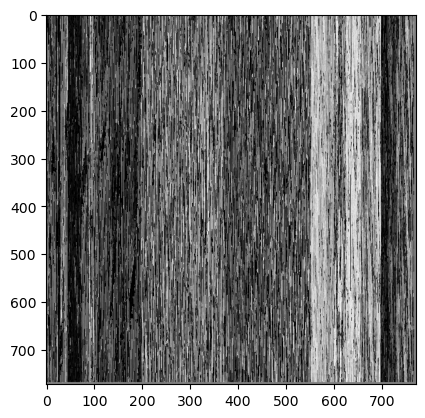

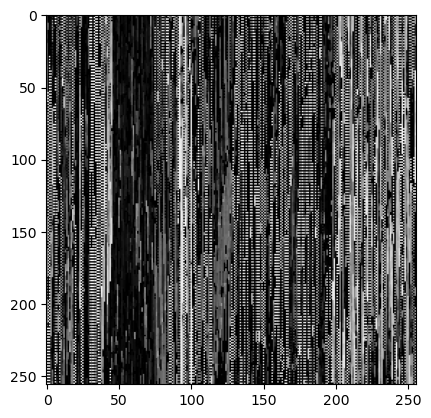

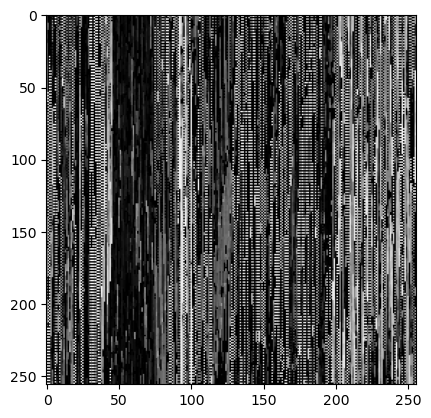

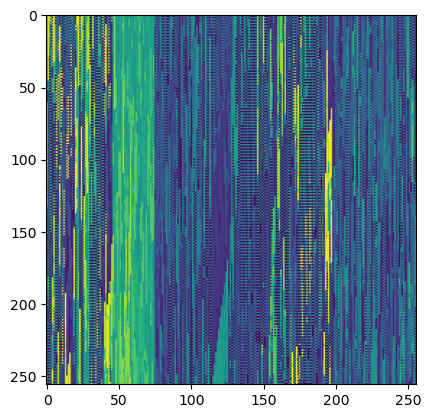

(289, 3, 256, 256)


In [13]:
#Reconstructing the whole image from data
ylabelReconstruct = np.zeros((1,h,w))
ylabelIterator = 0
for j in range(0,w-s,step):
    for i in range(0,h-s,step):
        ylabelReconstruct[0,i:i+s,j:j+s] = ylabel[ylabelIterator,0,:,:]
        ylabelIterator += 1
        
#Plot array as image with plt.imshow(array,cmap)
#Gray is 0--255, RGB is 0-1
i=0

fig = plt.figure()
plt.imshow(np.transpose(ylabelReconstruct[0,:,:])*255,cmap='gray')
plt.show()

fig = plt.figure()
plt.imshow(np.transpose(ylabel[i,0,:,:])*255,cmap='gray')
plt.show()

fig = plt.figure()
plt.imshow(np.transpose(ylabelNew[i,0,:,:])*255,cmap='gray')
plt.show()

fig = plt.figure()
plt.imshow(np.transpose(dataclipNew[i,0,:,:]),cmap='viridis')
plt.show()

#check shape of X data train
print(dataclipNew.shape)

 ### TEST DATA

In [14]:
#import data
dft = pd.read_csv('N_A_stack4.csv')

print(dft.columns)

Index(['light', 'Shadow', 'VGA', 'Newid', 'GPS'], dtype='object')


In [15]:



#Transform to numpy
datatest=np.array(dft[['Newid','light', 'Shadow', 'GPS']])
#print(datatest.shape)

datatest=np.transpose(datatest)

datatest= datatest.reshape(4,408,432)
#print(datatest.shape)

#Divide into set
w=432 #width
h=408 #height
s=256 #size
step=24 #step

datacliptest_list = []

idvaltest_list = []

for j in range(0,w-s+1,step):
    for i in range(0,h-s+1,step):
        #take slice from data of size [s x s] 
        sample = datatest[1:,i:i+s,j:j+s]
        sampleID = datatest[0,i:i+s,j:j+s]

        datacliptest_list.append(sample)
        idvaltest_list.append(sampleID)

datacliptest = np.stack(datacliptest_list, axis=0)
idvaltest = np.stack(idvaltest_list, axis=0)

#Normalize the data using train max per channel to [-1, 1]
datacliptest = (datacliptest / x_max[None,:,None,None]) * 2 - 1

In [16]:
datacliptest

array([[[[-0.46531338, -0.46531338, -0.46531338, ..., -0.63576252,
          -0.63576252, -0.63576252],
         [-0.46531338, -0.46531338, -0.46531338, ..., -0.63576252,
          -0.63576252, -0.63576252],
         [-0.46531338, -0.46531338, -0.46531338, ..., -0.63576252,
          -0.63576252, -0.63576252],
         ...,
         [-0.3075145 , -0.30750049, -0.30750049, ..., -0.45832283,
          -0.45832283, -0.4377294 ],
         [-0.3075145 , -0.30750049, -0.30750049, ..., -0.45832283,
          -0.45832283, -0.4377294 ],
         [-0.3075145 , -0.30750049, -0.30750049, ..., -0.45832283,
          -0.45832283, -0.4377294 ]],

        [[-2.35849057, -1.28301887, -1.84669811, ..., -0.43632075,
          -2.25707547, -2.0259434 ],
         [-0.92216981, -2.38443396, -2.0259434 , ..., -0.07783019,
          -1.28301887, -2.17924528],
         [-1.66745283, -1.9740566 , -1.56367925, ..., -0.15330189,
           0.15330189, -2.        ],
         ...,
         [-0.89858491, -1.15330189

In [17]:
#### This part was made for checking the height and weight.


'''
import matplotlib.pyplot as plt
import numpy as np

# 1. 提取 GPS 列的原始数据 (展平状态)
gps_flat = dft['GPS'].values 

# 2. 设置绘图
plt.figure(figsize=(16, 8))

# --- 情况 A: 你的代码当前写法 (Height=432, Width=408) ---
plt.subplot(1, 2, 1)
try:
    # 尝试按照 (432行, 408列) 重组
    gps_img_A = gps_flat.reshape(432, 408)
    plt.imshow(gps_img_A, cmap='Spectral') # 使用彩虹色谱，对比明显
    plt.colorbar()
    plt.title(f"Case A: Height=432, Width=408\n(Current Code)")
    plt.xlabel("Width axis (0-408)")
    plt.ylabel("Height axis (0-432)")
except ValueError as e:
    plt.text(0.5, 0.5, f"Error: Cannot reshape to (432,408)\n{e}", ha='center')

# --- 情况 B: 另一种可能性 (Height=408, Width=432) ---
plt.subplot(1, 2, 2)
try:
    # 尝试按照 (408行, 432列) 重组
    gps_img_B = gps_flat.reshape(408, 432)
    plt.imshow(gps_img_B, cmap='Spectral')
    plt.colorbar()
    plt.title(f"Case B: Height=408, Width=432\n(Alternative)")
    plt.xlabel("Width axis (0-432)")
    plt.ylabel("Height axis (0-408)")
except ValueError as e:
    plt.text(0.5, 0.5, f"Error: Cannot reshape to (408,432)\n{e}", ha='center')

plt.tight_layout()
plt.show()
'''

'\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# 1. 提取 GPS 列的原始数据 (展平状态)\ngps_flat = dft[\'GPS\'].values \n\n# 2. 设置绘图\nplt.figure(figsize=(16, 8))\n\n# --- 情况 A: 你的代码当前写法 (Height=432, Width=408) ---\nplt.subplot(1, 2, 1)\ntry:\n    # 尝试按照 (432行, 408列) 重组\n    gps_img_A = gps_flat.reshape(432, 408)\n    plt.imshow(gps_img_A, cmap=\'Spectral\') # 使用彩虹色谱，对比明显\n    plt.colorbar()\n    plt.title(f"Case A: Height=432, Width=408\n(Current Code)")\n    plt.xlabel("Width axis (0-408)")\n    plt.ylabel("Height axis (0-432)")\nexcept ValueError as e:\n    plt.text(0.5, 0.5, f"Error: Cannot reshape to (432,408)\n{e}", ha=\'center\')\n\n# --- 情况 B: 另一种可能性 (Height=408, Width=432) ---\nplt.subplot(1, 2, 2)\ntry:\n    # 尝试按照 (408行, 432列) 重组\n    gps_img_B = gps_flat.reshape(408, 432)\n    plt.imshow(gps_img_B, cmap=\'Spectral\')\n    plt.colorbar()\n    plt.title(f"Case B: Height=408, Width=432\n(Alternative)")\n    plt.xlabel("Width axis (0-432)")\n    plt.ylabel("Height axis (0-408)")\ne

 ### TRAIN THE MODEL

In [18]:
#Configurations
disc = Discriminator(in_channels_x=3, in_channels_y=1).to(DEVICE)
gen = Generator(in_channels=3, out_channels=1, features=64).to(DEVICE)
opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999),)
opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
BCE = nn.BCEWithLogitsLoss()
L1_LOSS = nn.L1Loss()

if LOAD_MODEL:
   load_checkpoint(
       CHECKPOINT_GEN, gen, opt_gen, LEARNING_RATE,
   )
   load_checkpoint(
       CHECKPOINT_DISC, disc, opt_disc, LEARNING_RATE,
   )

#Train the model
from torch.utils.data import TensorDataset


##ADDITION
tensor_x = torch.Tensor(dataclipNew) # transform to torch tensor
tensor_y = torch.Tensor(ylabelNew)

train_dataset = TensorDataset(tensor_x,tensor_y) # create your datset
##

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,)

g_scaler = torch.cuda.amp.GradScaler()
d_scaler = torch.cuda.amp.GradScaler()


for epoch in range(NUM_EPOCHS):
    print('epoch is',epoch)
    train_fn(disc, gen, train_loader, opt_disc, opt_gen, L1_LOSS, BCE, g_scaler, d_scaler)
    
    if SAVE_MODEL and epoch % 5 == 0:
        save_checkpoint(gen, opt_gen, filename = CHECKPOINT_GEN)
        save_checkpoint(disc, opt_disc, filename = CHECKPOINT_DISC)


##ADDITION : Save the last epoch
save_checkpoint(gen, opt_gen, filename = CHECKPOINT_GEN)
save_checkpoint(disc, opt_disc, filename = CHECKPOINT_DISC)
##

# Results: Ideally we need D_fake=0 and D_real=1

epoch is 0


100%|██████████████████████████████████████████████████████| 17/17 [00:04<00:00,  3.68it/s, D_fake=0.461, D_real=0.516]


=> Saving checkpoint
=> Saving checkpoint
epoch is 1


100%|██████████████████████████████████████████████████████| 17/17 [00:03<00:00,  5.61it/s, D_fake=0.425, D_real=0.569]


epoch is 2


...

epoch is 18


100%|████████████████████████████████████████████████████████| 17/17 [00:02<00:00,  5.79it/s, D_fake=0.5, D_real=0.506]


epoch is 19


100%|██████████████████████████████████████████████████████| 17/17 [00:02<00:00,  5.78it/s, D_fake=0.494, D_real=0.509]


=> Saving checkpoint
=> Saving checkpoint


### TEST THE MODEL

In [19]:
#TEST each image individually
for i in range(len(datacliptest)):
    
    tensor_x = torch.Tensor(datacliptest[i].reshape(1,3,256,256)) # transform to torch tensor
    
    #We can use a fake test target/ we only need it as placeholder
    testRandomY = np.empty((1,1,256,256))
    tensor_y = torch.Tensor(testRandomY)
    
    val_dataset = TensorDataset(tensor_x,tensor_y) # create your datset
    
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
    
    save_some_examples(gen, val_loader, 19, folder="evaluation", iteration=i) #Remember to choose the epoch
#remember to create the folder evaluation on the same filepath as the jupyter notebook

### SAVE THE RESULTS (CSV)

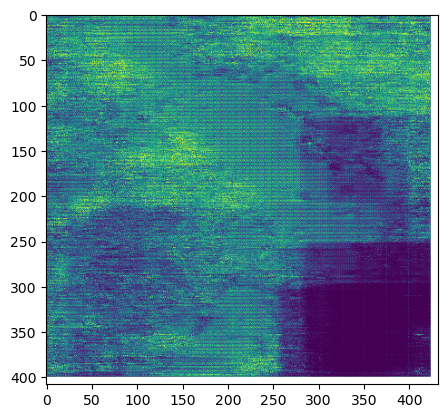

In [20]:
nSamples = len(datacliptest)
yFull = np.zeros((nSamples,1,256,256))

for i in range(len(datacliptest)): 
    yFull[i] = np.load(f"ypred_{i}.npy")

h=408
w=432
##Visualising the image
#Reconstructing the whole image from the NN results
yReconstruct = np.zeros((1, h, w))      # 填 (1, 432, 408)
idReconstruct = np.zeros((h, w))        # 填 (432, 408)
yWeight = np.zeros((h, w))              # 填 (432, 408)
ylabelIterator = 0

for j in range(0, w - s + 1, step):      # 这里填 408 (即 w)
    
    # 【修正点3】：内层循环 i 对应高度 (h=432)
    for i in range(0, h - s + 1, step):  # 这里填 432 (即 h)
        
        # 写入数据
        # i 控制第2维 (高度/432), j 控制第3维 (宽度/408)
        yReconstruct[:, i:i+s, j:j+s] += yFull[ylabelIterator,:,:,:]
        idReconstruct[i:i+s, j:j+s] += idvaltest[ylabelIterator,:,:] # 注意: idvaltest 需要确保存在
        yWeight[i:i+s, j:j+s] += 1
        ylabelIterator += 1

yReconstruct = yReconstruct / yWeight[None,:,:]
idReconstruct = idReconstruct / yWeight

fig = plt.figure()
plt.imshow(yReconstruct[0],cmap='viridis')
plt.show()

# Reshape multidimensional array to get it as list
yReconstruct = yReconstruct.reshape(1,-1)
idReconstruct = idReconstruct.reshape(-1)

# Construct a dataframe from the NN outputs and save as csv
dfy=pd.DataFrame(idReconstruct[:],columns=['id'])
dfy['ch1']= yReconstruct[0,:]
dfy.to_csv(f'./_pred_LG.csv',index=False)


In [21]:
step

24